In [1]:
import pandas as pd
import glob
import os

base_dir = r"D:\BLA_ChR_resp"

folders = [
    os.path.join(base_dir, "RI1_day1_boris"),
    os.path.join(base_dir, "RI1_day2_boris")
]

files = []
for f in folders:
    files.extend(glob.glob(os.path.join(f, "*.csv")))

# 🚫 Exclude social-agent scoring
files = [f for f in files if not f.endswith("_sa.csv")]

len(files)


46

In [2]:
def load_boris_for_inspection(csv_path):
    df = pd.read_csv(csv_path)

    # --- Standardize timing column names ---
    df = df.rename(columns={
        "Start (s)": "Start",
        "Stop (s)": "Stop",
        "Duration (s)": "Duration"
    })

    # --- Keep only columns needed to LOOK at behavior ---
    keep_cols = [
        "Behavior",
        "Behavior type",
        "Subject",              # BORIS role: subject / agent
        "Start",
        "Stop",
        "Duration",
        "FPS (frame/s)",
        "Image index start",
        "Image index stop",
        "Media file name"
    ]
    keep_cols = [c for c in keep_cols if c in df.columns]
    df = df[keep_cols].copy()

    # --- Light cleaning ---
    df["Behavior"] = df["Behavior"].astype(str).str.strip().str.lower()
    df["Subject"] = df["Subject"].astype(str).str.strip().str.lower()

    # ============================
    # ADD METADATA FROM FILENAME
    # ============================
    fname = os.path.basename(csv_path)
    parts = fname.replace(".csv", "").split("_")

    # Subject ID = cage_mouse (e.g. 1_2)
    cage = parts[0]
    mouse = parts[1]
    subject_id = f"{cage}_{mouse}"

    # Laser condition
    laser = "ON" if "on" in parts else "OFF"

    df["SubjectID"] = subject_id
    df["Laser"] = laser

    return df


In [3]:
dfs = []
for f in files:
    df = load_boris_for_inspection(f)
    df["File"] = os.path.basename(f)
    dfs.append(df)

boris_df = pd.concat(dfs, ignore_index=True)



In [4]:
boris_df = boris_df.copy()

# Extract cage number from SubjectID (e.g. "3_2" → 3)
boris_df["Cage"] = boris_df["SubjectID"].str.split("_").str[0].astype(int)

# Assign group
boris_df["Group"] = boris_df["Cage"].apply(
    lambda x: "GFP" if x % 2 == 0 else "ChR-YFP"
)


In [5]:
boris_df.columns


Index(['Behavior', 'Behavior type', 'Subject', 'Start', 'Stop', 'Duration',
       'FPS (frame/s)', 'Image index start', 'Image index stop',
       'Media file name', 'SubjectID', 'Laser', 'File', 'Cage', 'Group'],
      dtype='object')

In [6]:
boris_df.shape
boris_df.head()


,Behavior,Behavior type,Subject,Start,Stop,Duration,FPS (frame/s),Image index start,Image index stop,Media file name,SubjectID,Laser,File,Cage,Group
0,facial sniffing,STATE,subject,60.938,62.437,1.499,16.0,975.0,NaN,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
1,anogenital sniffing,STATE,subject,62.438,64.938,2.500,16.0,999.0,1039.0,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
2,chasing,STATE,subject,65.375,67.062,1.687,16.0,1046.0,1073.0,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
3,anogenital sniffing,STATE,subject,67.438,68.437,0.999,16.0,1079.0,NaN,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
4,body sniffing,STATE,subject,68.438,71.062,2.624,16.0,1095.0,1137.0,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP


In [7]:
boris_df

,Behavior,Behavior type,Subject,Start,Stop,Duration,FPS (frame/s),Image index start,Image index stop,Media file name,SubjectID,Laser,File,Cage,Group
0,facial sniffing,STATE,subject,60.938,62.437,1.499,16.0,975.0,NaN,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
1,anogenital sniffing,STATE,subject,62.438,64.938,2.500,16.0,999.0,1039.0,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
2,chasing,STATE,subject,65.375,67.062,1.687,16.0,1046.0,1073.0,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
3,anogenital sniffing,STATE,subject,67.438,68.437,0.999,16.0,1079.0,NaN,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
4,body sniffing,STATE,subject,68.438,71.062,2.624,16.0,1095.0,1137.0,C:/Users/taylo/Downloads/1_1_RI1_f1_d_on_20260...,1_1,ON,1_1_RI1_f1_d_on_VT_BORIS_day1.csv,1,ChR-YFP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1887,facial sniffing,STATE,subject,132.562,133.438,0.876,16.0,2122.0,2136.0,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/...,9_1,OFF,9_1_RI1_m1_j_off_20260112_123836.1_BORIS.csv,9,ChR-YFP
1888,body sniffing,STATE,subject,133.562,134.438,0.876,16.0,2138.0,2152.0,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/...,9_1,OFF,9_1_RI1_m1_j_off_20260112_123836.1_BORIS.csv,9,ChR-YFP
1889,anogenital sniffing,STATE,subject,135.312,136.000,0.688,16.0,2166.0,2177.0,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/...,9_1,OFF,9_1_RI1_m1_j_off_20260112_123836.1_BORIS.csv,9,ChR-YFP
1890,facial sniffing,STATE,subject,157.750,158.312,0.562,16.0,2525.0,2534.0,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/...,9_1,OFF,9_1_RI1_m1_j_off_20260112_123836.1_BORIS.csv,9,ChR-YFP


In [8]:
bout_counts = (
    boris_df
    .groupby(["SubjectID", "Group", "Laser", "Behavior"], as_index=False)
    .size()
    .rename(columns={"size": "BoutCount"})
)


In [9]:
bout_counts.head()


,SubjectID,Group,Laser,Behavior,BoutCount
0,1_1,ChR-YFP,OFF,anogenital sniffing,13
1,1_1,ChR-YFP,OFF,body sniffing,6
2,1_1,ChR-YFP,OFF,chasing,2
3,1_1,ChR-YFP,OFF,facial sniffing,8
4,1_1,ChR-YFP,ON,anogenital sniffing,14


In [10]:
paired = (
    bout_counts
    .groupby(["SubjectID", "Group", "Behavior"])["Laser"]
    .nunique()
    .reset_index()
)

paired = paired[paired["Laser"] == 2]   # must have ON + OFF

bout_counts_paired = bout_counts.merge(
    paired[["SubjectID", "Group", "Behavior"]],
    on=["SubjectID", "Group", "Behavior"],
    how="inner"
)


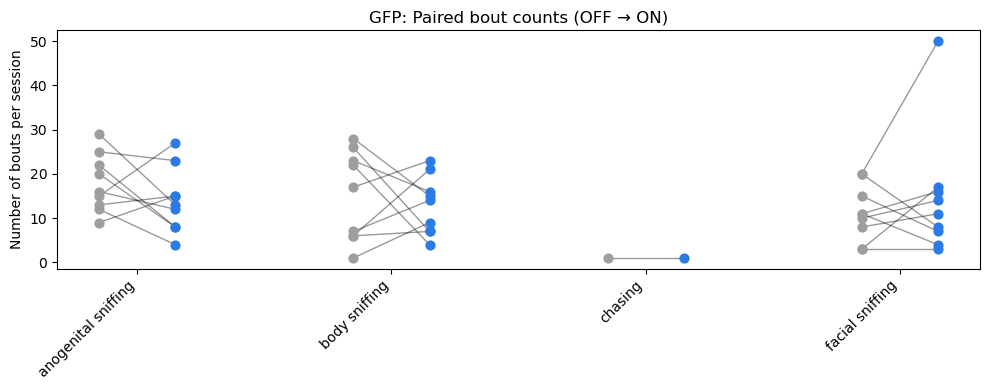

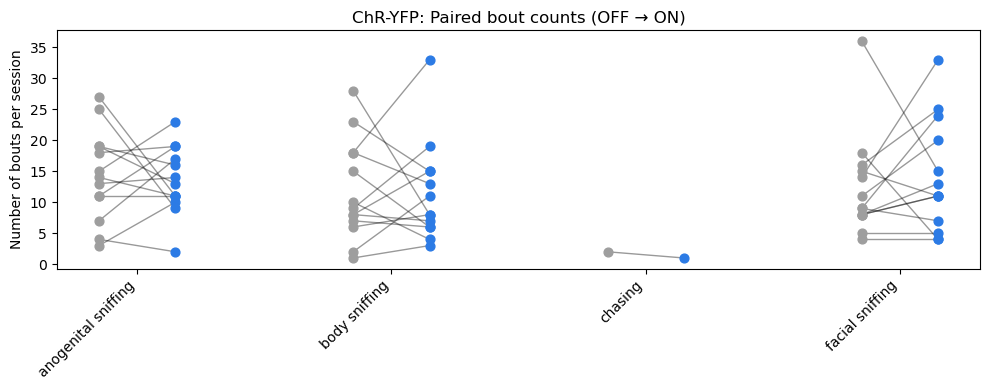

In [11]:
import matplotlib.pyplot as plt

groups = ["GFP", "ChR-YFP"]
colors = {"OFF": "#9E9E9E", "ON": "#2C7BE5"}  # gray / blue

for group in groups:
    plt.figure(figsize=(10,4))

    gdf = bout_counts_paired[bout_counts_paired["Group"] == group]

    behaviors = sorted(gdf["Behavior"].unique())
    x_pos = {b: i for i, b in enumerate(behaviors)}

    for (subj, beh), sdf in gdf.groupby(["SubjectID", "Behavior"]):
        wide = sdf.pivot(index="SubjectID", columns="Laser", values="BoutCount")

        if not {"OFF", "ON"}.issubset(wide.columns):
            continue

        x = x_pos[beh]
        plt.plot(
            [x - 0.15, x + 0.15],
            [wide.loc[subj, "OFF"], wide.loc[subj, "ON"]],
            color="black",
            alpha=0.4,
            linewidth=1
        )

        plt.scatter(x - 0.15, wide.loc[subj, "OFF"], color=colors["OFF"], s=40, zorder=3)
        plt.scatter(x + 0.15, wide.loc[subj, "ON"],  color=colors["ON"],  s=40, zorder=3)

    plt.xticks(range(len(behaviors)), behaviors, rotation=45, ha="right")
    plt.ylabel("Number of bouts per session")
    plt.title(f"{group}: Paired bout counts (OFF → ON)")
    plt.tight_layout()
    plt.show()


In [12]:
print(bout_counts_paired.columns)


Index(['SubjectID', 'Group', 'Laser', 'Behavior', 'BoutCount'], dtype='object')


In [13]:
def infer_sex(subject_id):
    cage = int(subject_id.split("_")[0])
    if cage <= 4:
        return "Female"
    else:
        return "Male"

bout_counts_paired["Sex"] = bout_counts_paired["SubjectID"].apply(infer_sex)


In [14]:
print(bout_counts_paired["Sex"].value_counts())


Sex
Female    68
Male      68
Name: count, dtype: int64


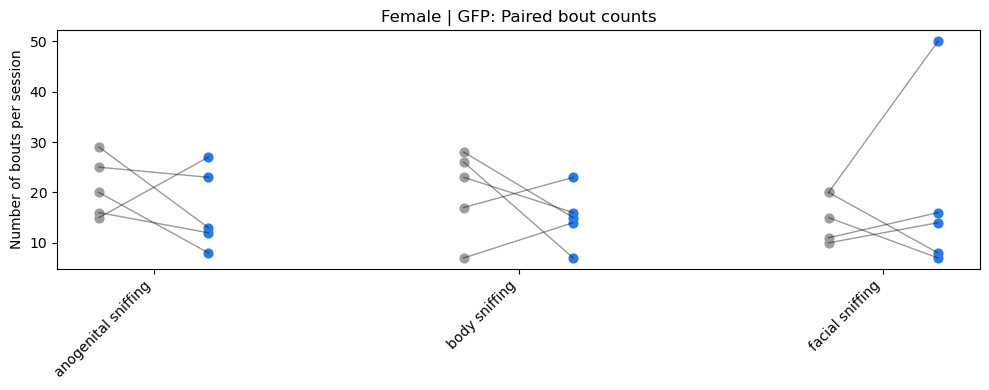

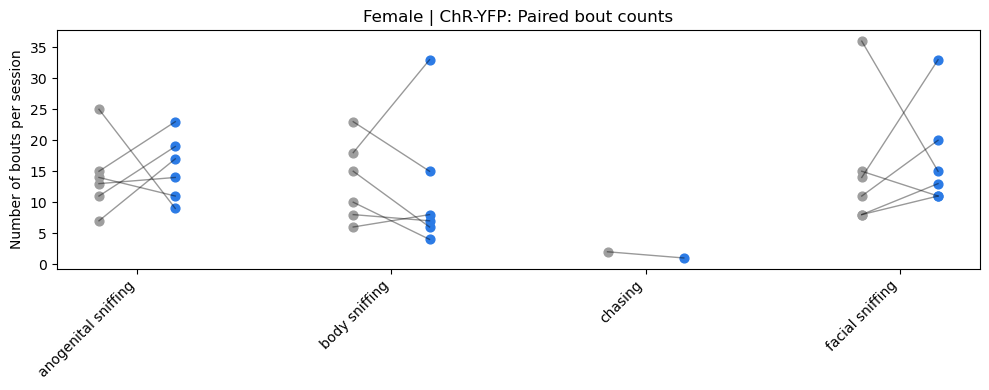

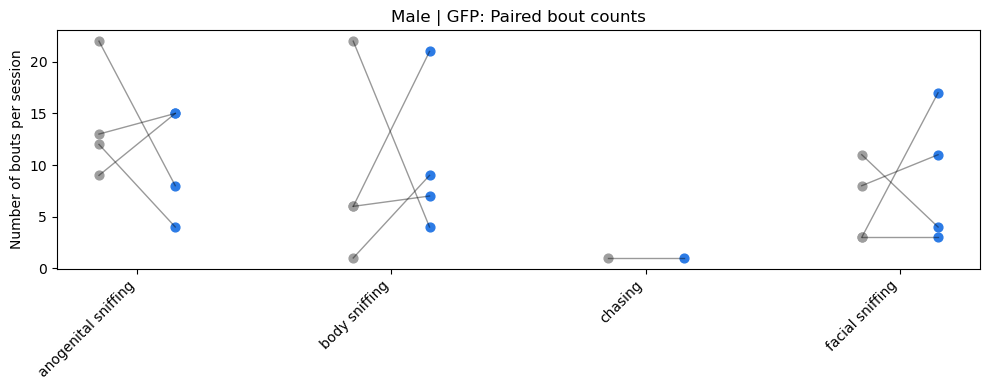

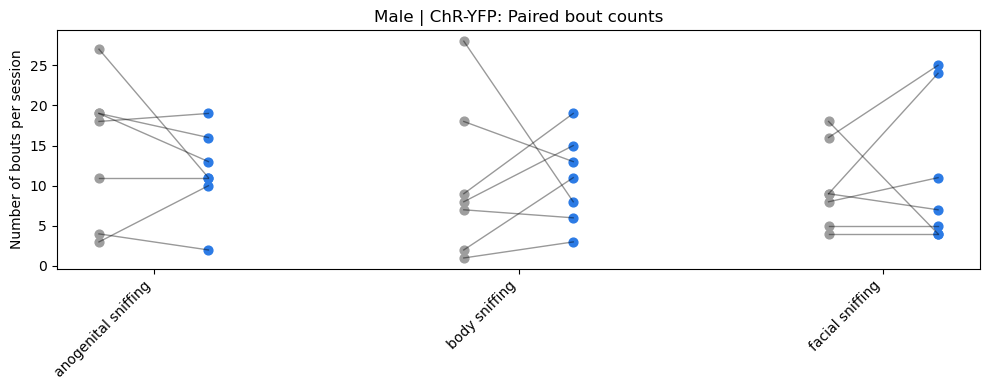

In [15]:
import matplotlib.pyplot as plt

groups = ["GFP", "ChR-YFP"]
sexes = ["Female", "Male"]

colors = {"OFF": "#9E9E9E", "ON": "#2C7BE5"}

for sex in sexes:
    for group in groups:

        plt.figure(figsize=(10,4))

        gdf = bout_counts_paired[
            (bout_counts_paired["Group"] == group) &
            (bout_counts_paired["Sex"] == sex)
        ]

        behaviors = sorted(gdf["Behavior"].unique())
        x_pos = {b: i for i, b in enumerate(behaviors)}

        for (subj, beh), sdf in gdf.groupby(["SubjectID", "Behavior"]):

            wide = sdf.pivot(index="SubjectID", columns="Laser", values="BoutCount")

            if not {"OFF", "ON"}.issubset(wide.columns):
                continue

            x = x_pos[beh]

            plt.plot(
                [x - 0.15, x + 0.15],
                [wide.loc[subj, "OFF"], wide.loc[subj, "ON"]],
                color="black",
                alpha=0.4,
                linewidth=1
            )

            plt.scatter(x - 0.15, wide.loc[subj, "OFF"], color=colors["OFF"], s=40)
            plt.scatter(x + 0.15, wide.loc[subj, "ON"],  color=colors["ON"],  s=40)

        plt.xticks(range(len(behaviors)), behaviors, rotation=45, ha="right")
        plt.ylabel("Number of bouts per session")
        plt.title(f"{sex} | {group}: Paired bout counts")
        plt.tight_layout()
        plt.show()



In [16]:
investigation_behaviors = [
    "facial sniffing",
    "body sniffing",
    "anogenital sniffing"
]


In [17]:
invest_df = boris_df[
    boris_df["Behavior"].isin(investigation_behaviors)
].copy()

invest_time = (
    invest_df
    .groupby(["SubjectID", "Group", "Laser"], as_index=False)
    .agg(InvestigationTime=("Duration", "sum"))
)


In [18]:
invest_time.head()
invest_time.groupby(["Group", "Laser"]).size()


Group    Laser
ChR-YFP  OFF      13
         ON       13
GFP      OFF       9
         ON       11
dtype: int64

In [19]:
file_presence = (
    boris_df
    .groupby(["SubjectID", "Group", "Laser"])["File"]
    .nunique()
    .reset_index(name="N_files")
)

file_presence[file_presence["SubjectID"].isin(["2_2", "8_2"])]


,SubjectID,Group,Laser,N_files
8,2_2,GFP,ON,1
41,8_2,GFP,ON,1


In [20]:
investigation_behaviors = [
    "facial sniffing",
    "body sniffing",
    "anogenital sniffing"
]

invest_presence = (
    boris_df[
        boris_df["Behavior"].isin(investigation_behaviors)
    ]
    .groupby(["SubjectID", "Group", "Laser"])["Duration"]
    .sum()
    .reset_index(name="TotalInvestigationTime")
)

invest_presence[invest_presence["SubjectID"].isin(["2_2", "8_2"])]


,SubjectID,Group,Laser,TotalInvestigationTime
8,2_2,GFP,ON,67.498
41,8_2,GFP,ON,34.960


In [21]:
diagnostic = (
    file_presence
    .merge(
        invest_presence,
        on=["SubjectID", "Group", "Laser"],
        how="left"
    )
    .fillna({"TotalInvestigationTime": 0})
)

diagnostic[diagnostic["SubjectID"].isin(["2_2", "8_2"])]


,SubjectID,Group,Laser,N_files,TotalInvestigationTime
8,2_2,GFP,ON,1,67.498
41,8_2,GFP,ON,1,34.960


In [22]:
file_table = (
    boris_df
    .groupby(["SubjectID", "Group", "Laser"])["File"]
    .nunique()
    .reset_index(name="N_files")
)

file_table.sort_values(["Group", "SubjectID", "Laser"])


,SubjectID,Group,Laser,N_files
0,1_1,ChR-YFP,OFF,1
1,1_1,ChR-YFP,ON,1
2,1_2,ChR-YFP,OFF,1
3,1_2,ChR-YFP,ON,1
4,1_3,ChR-YFP,OFF,1
5,1_3,ChR-YFP,ON,1
11,3_1,ChR-YFP,OFF,1
12,3_1,ChR-YFP,ON,1
13,3_2,ChR-YFP,OFF,1
14,3_2,ChR-YFP,ON,1


In [23]:
# All OFF sessions (regardless of behavior)
all_off_files = (
    boris_df[boris_df["Laser"] == "OFF"]
    .groupby(["SubjectID", "Group"])["File"]
    .nunique()
    .reset_index(name="N_OFF_files")
)

# OFF sessions WITH investigation
off_invest = (
    boris_df[
        (boris_df["Laser"] == "OFF") &
        (boris_df["Behavior"].isin([
            "facial sniffing",
            "body sniffing",
            "anogenital sniffing"
        ]))
    ]
    .groupby(["SubjectID", "Group"])["File"]
    .nunique()
    .reset_index(name="N_OFF_invest_files")
)

check = (
    all_off_files
    .merge(off_invest, on=["SubjectID", "Group"], how="left")
    .fillna({"N_OFF_invest_files": 0})
)

check[check["Group"] == "GFP"]


,SubjectID,Group,N_OFF_files,N_OFF_invest_files
3,2_1,GFP,1,1
4,2_3,GFP,1,1
8,4_1,GFP,1,1
9,4_2,GFP,1,1
10,4_3,GFP,1,1
14,6_2,GFP,1,1
15,6_3,GFP,1,1
19,8_1,GFP,1,1
20,8_3,GFP,1,1


In [24]:
exclude_subjects = ["2_2", "8_2"]

invest_time_paired = invest_time[
    ~invest_time["SubjectID"].isin(exclude_subjects)
].copy()


In [25]:
paired_subjects = (
    invest_time
    .groupby(["SubjectID", "Group"])["Laser"]
    .nunique()
    .reset_index()
    .query("Laser == 2")
)

invest_time_paired = invest_time.merge(
    paired_subjects[["SubjectID", "Group"]],
    on=["SubjectID", "Group"],
    how="inner"
)


In [26]:
invest_time_paired.groupby(["Group", "Laser"]).size()


Group    Laser
ChR-YFP  OFF      13
         ON       13
GFP      OFF       9
         ON        9
dtype: int64

In [27]:
invest_plot = invest_time_paired.copy()


In [28]:
invest_plot.columns


Index(['SubjectID', 'Group', 'Laser', 'InvestigationTime'], dtype='object')

C:\Users\sjs93\AppData\Local\Temp\ipykernel_19064\2589877615.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


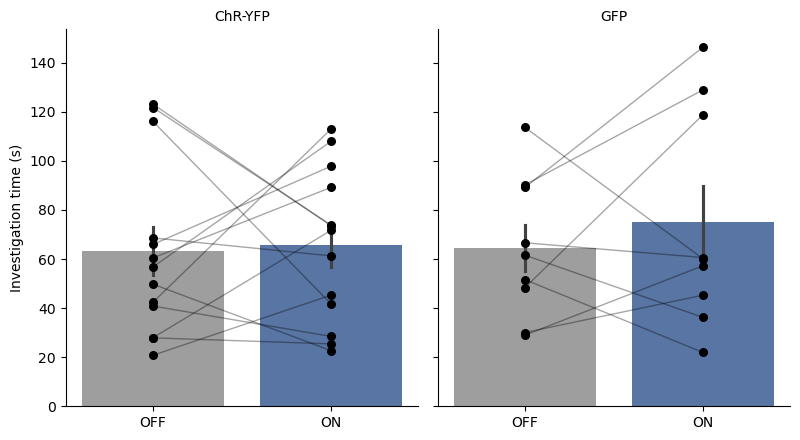

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

palette_laser = {
    "OFF": "#9E9E9E",  # gray
    "ON":  "#4C72B0"   # blue
}

g = sns.catplot(
    data=invest_plot,
    x="Laser",
    y="InvestigationTime",
    col="Group",
    kind="bar",
    palette=palette_laser,
    errorbar="se",      # ✅ FIXED
    height=4.5,
    aspect=0.9,
    sharey=True
)

# Overlay paired points + lines
for ax, (group, df_group) in zip(g.axes.flat, invest_plot.groupby("Group")):
    for subject, df_sub in df_group.groupby("SubjectID"):
        if set(df_sub["Laser"]) == {"ON", "OFF"}:
            df_sub = df_sub.sort_values("Laser")
            ax.plot(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.35,
                linewidth=1,
                zorder=3
            )
            ax.scatter(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                color="black",
                s=30,
                zorder=4
            )

g.set_axis_labels("", "Investigation time (s)")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_19064\3371639298.py:33: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


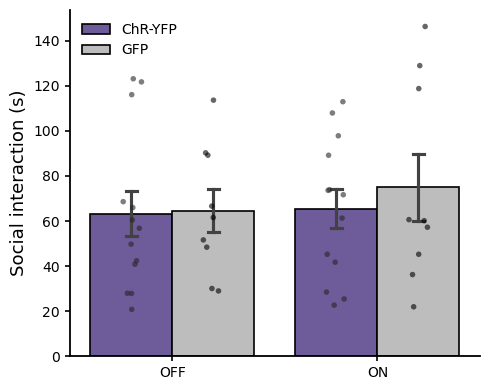

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Orders ---
laser_order = ["OFF", "ON"]
group_order = ["ChR-YFP", "GFP"]

# --- Colors ---
group_palette = {
    "ChR-YFP": "#6A51A3",  # purple
    "GFP": "#BDBDBD"       # gray
}

plt.figure(figsize=(5, 4))

# --- Bar plot (mean ± SEM) ---
sns.barplot(
    data=invest_plot,
    x="Laser",
    y="InvestigationTime",
    hue="Group",
    order=laser_order,
    hue_order=group_order,
    errorbar="se",
    palette=group_palette,
    edgecolor="black",
    linewidth=1.2,
    capsize=0.1
)

# --- Overlay jittered individual points ---
sns.stripplot(
    data=invest_plot,
    x="Laser",
    y="InvestigationTime",
    hue="Group",
    order=laser_order,
    hue_order=group_order,
    dodge=True,
    color="black",
    size=4,
    alpha=0.6
)

# --- Clean up double legend (stripplot adds another) ---
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], frameon=False)

# --- Style like paper ---
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.3)
ax.spines["bottom"].set_linewidth(1.3)

ax.set_ylabel("Social interaction (s)", fontsize=13)
ax.set_xlabel("")
ax.tick_params(width=1.2)

plt.tight_layout()
plt.show()


In [35]:
print(invest_plot["Group"].unique())
print(invest_plot["Laser"].unique())
print(invest_plot.head())


['ChR-YFP' 'GFP']
['OFF' 'ON']
  SubjectID    Group Laser  InvestigationTime
0       1_1  ChR-YFP   OFF             68.601
1       1_1  ChR-YFP    ON             61.296
2       1_2  ChR-YFP   OFF             40.841
3       1_2  ChR-YFP    ON             28.480
4       1_3  ChR-YFP   OFF            116.066


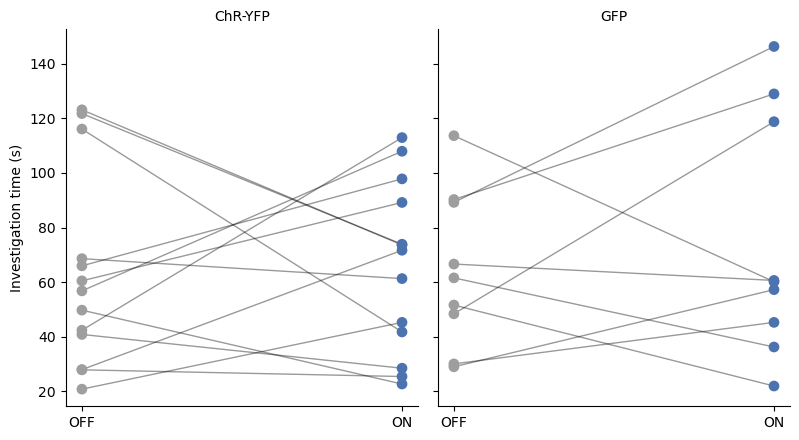

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

palette_laser = {
    "OFF": "#9E9E9E",  # gray
    "ON":  "#4C72B0"   # blue
}

g = sns.FacetGrid(
    invest_plot,
    col="Group",
    sharey=True,
    height=4.5,
    aspect=0.9
)

def paired_lines(data, **kwargs):
    ax = plt.gca()
    for subject, df_sub in data.groupby("SubjectID"):
        if set(df_sub["Laser"]) == {"ON", "OFF"}:
            df_sub = df_sub.sort_values("Laser")  # OFF -> ON
            ax.plot(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.4,
                linewidth=1
            )
            ax.scatter(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                c=[palette_laser[l] for l in df_sub["Laser"]],
                s=45,
                zorder=3
            )

g.map_dataframe(paired_lines)

g.set_axis_labels("", "Investigation time (s)")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()


In [32]:
(
    boris_df
    .assign(
        Behavior=lambda df: df["Behavior"].astype(str).str.strip().str.lower()
    )
    .pivot_table(
        index=["Behavior", "Group"],
        columns="Laser",
        values="File",     # any column works, we just count rows
        aggfunc="count",
        fill_value=0
    )
    .sort_values(["Group"], ascending=True)
)


,Laser,OFF,ON
Behavior,Group,,
allogrooming,ChR-YFP,3,0
anogenital sniffing,ChR-YFP,186,175
body sniffing,ChR-YFP,153,148
chasing,ChR-YFP,8,6
facial sniffing,ChR-YFP,161,183
self-grooming,ChR-YFP,1,3
anogenital sniffing,GFP,161,151
body sniffing,GFP,136,136
chasing,GFP,6,23


C:\Users\sjs93\AppData\Local\Temp\ipykernel_19064\1987565655.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
C:\Users\sjs93\AppData\Local\Temp\ipykernel_19064\1987565655.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


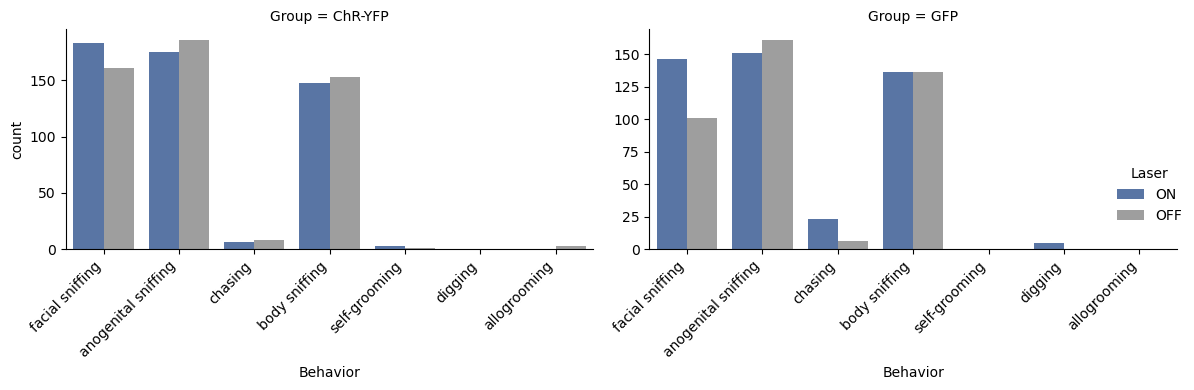

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

palette_laser = {
    "OFF": "#9E9E9E",  # gray
    "ON":  "#4C72B0"   # blue
}

g = sns.catplot(
    data=boris_df.assign(
        Behavior=lambda df: df["Behavior"].astype(str).str.strip().str.lower()
    ),
    x="Behavior",
    hue="Laser",
    col="Group",
    kind="count",
    palette=palette_laser,
    height=4,
    aspect=1.4,
    sharey=False
)

# 🔄 Rotate x-axis labels to 45°
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()



In [39]:

(
    boris_df
    .assign(
        Behavior=lambda df: df["Behavior"].astype(str).str.strip().str.lower()
    )
    .groupby(["Group", "Laser", "Behavior"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Group", "Laser", "Count"], ascending=[True, True, False])
)



,Group,Laser,Behavior,Count
1,ChR-YFP,OFF,anogenital sniffing,186
4,ChR-YFP,OFF,facial sniffing,161
2,ChR-YFP,OFF,body sniffing,153
3,ChR-YFP,OFF,chasing,8
0,ChR-YFP,OFF,allogrooming,3
5,ChR-YFP,OFF,self-grooming,1
9,ChR-YFP,ON,facial sniffing,183
6,ChR-YFP,ON,anogenital sniffing,175
7,ChR-YFP,ON,body sniffing,148
8,ChR-YFP,ON,chasing,6


In [40]:
(
    boris_df["Behavior"]
    .astype(str)
    .str.strip()
    .str.lower()
    .value_counts()
)


Behavior
anogenital sniffing    673
facial sniffing        591
body sniffing          573
chasing                 43
digging                  5
self-grooming            4
allogrooming             3
Name: count, dtype: int64

In [41]:
exclude_behaviors = ["self-grooming", "digging"]

investigation_behaviors = (
    boris_df["Behavior"]
    .astype(str)
    .str.lower()
    .str.strip()
    .unique()
)

investigation_behaviors = [
    b for b in investigation_behaviors
    if b not in exclude_behaviors
]

investigation_behaviors


['facial sniffing',
 'anogenital sniffing',
 'chasing',
 'body sniffing',
 'allogrooming']

In [42]:
invest_time = (
    boris_df
    .assign(Behavior=lambda df: df["Behavior"].str.lower().str.strip())
    .query("Behavior in @investigation_behaviors")
    .groupby(["SubjectID", "Group", "Laser"], as_index=False)
    .agg(InvestigationTime=("Duration", "sum"))
)


In [43]:
paired_subjects = (
    invest_time
    .groupby(["SubjectID", "Group"])["Laser"]
    .nunique()
    .reset_index()
    .query("Laser == 2")
)

invest_plot = invest_time.merge(
    paired_subjects[["SubjectID", "Group"]],
    on=["SubjectID", "Group"],
    how="inner"
)


In [44]:
invest_plot.groupby(["Group", "Laser"]).size()


Group    Laser
ChR-YFP  OFF      13
         ON       13
GFP      OFF       9
         ON        9
dtype: int64

In [45]:
invest_plot.columns.tolist()


['SubjectID', 'Group', 'Laser', 'InvestigationTime']

In [46]:
def subject_to_sex(subject_id):
    cage = int(subject_id.split("_")[0])
    return "Female" if cage <= 4 else "Male"

invest_plot = invest_plot.copy()
invest_plot["SubjSex"] = invest_plot["SubjectID"].apply(subject_to_sex)


In [47]:
invest_plot[["SubjectID", "SubjSex"]].drop_duplicates().sort_values("SubjectID")


,SubjectID,SubjSex
0,1_1,Female
2,1_2,Female
4,1_3,Female
6,2_1,Female
8,2_3,Female
10,3_1,Female
12,3_2,Female
14,3_3,Female
16,4_1,Female
18,4_2,Female


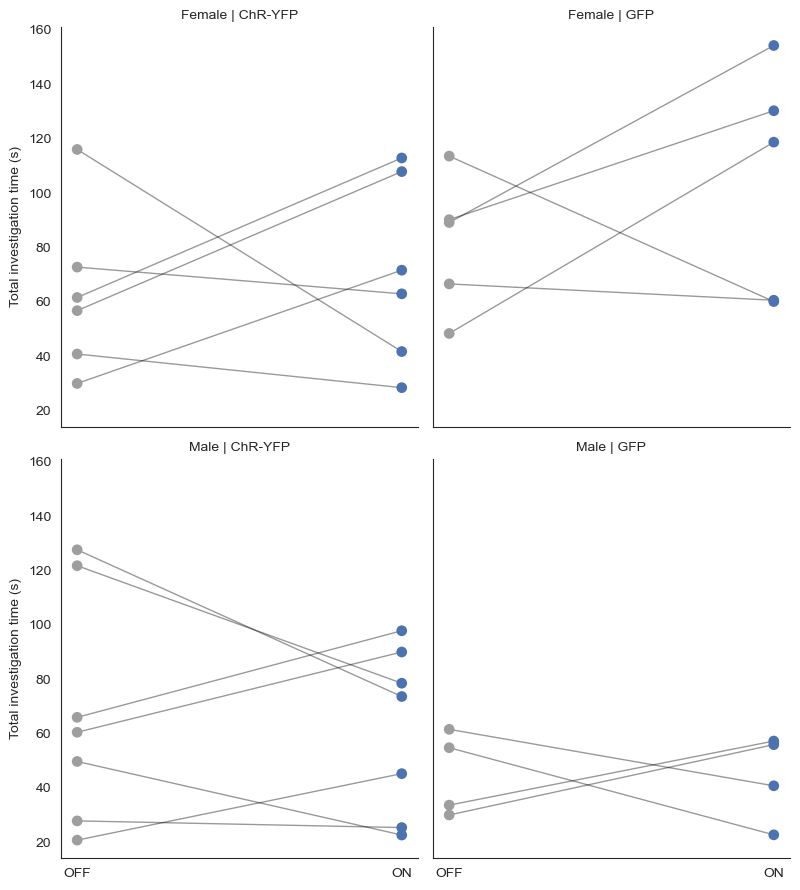

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

palette_laser = {
    "OFF": "#9E9E9E",  # gray
    "ON":  "#4C72B0"   # blue
}

g = sns.FacetGrid(
    invest_plot,
    row="SubjSex",
    col="Group",
    sharey=True,
    height=4.5,
    aspect=0.9
)

def paired_lines(data, **kwargs):
    ax = plt.gca()
    for subject, df_sub in data.groupby("SubjectID"):
        if set(df_sub["Laser"]) == {"OFF", "ON"}:
            df_sub = df_sub.sort_values("Laser")
            ax.plot(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.4,
                linewidth=1
            )
            ax.scatter(
                df_sub["Laser"],
                df_sub["InvestigationTime"],
                c=[palette_laser[l] for l in df_sub["Laser"]],
                s=45,
                zorder=3
            )

g.map_dataframe(paired_lines)

g.set_axis_labels("", "Total investigation time (s)")
g.set_titles("{row_name} | {col_name}")
plt.tight_layout()
plt.show()


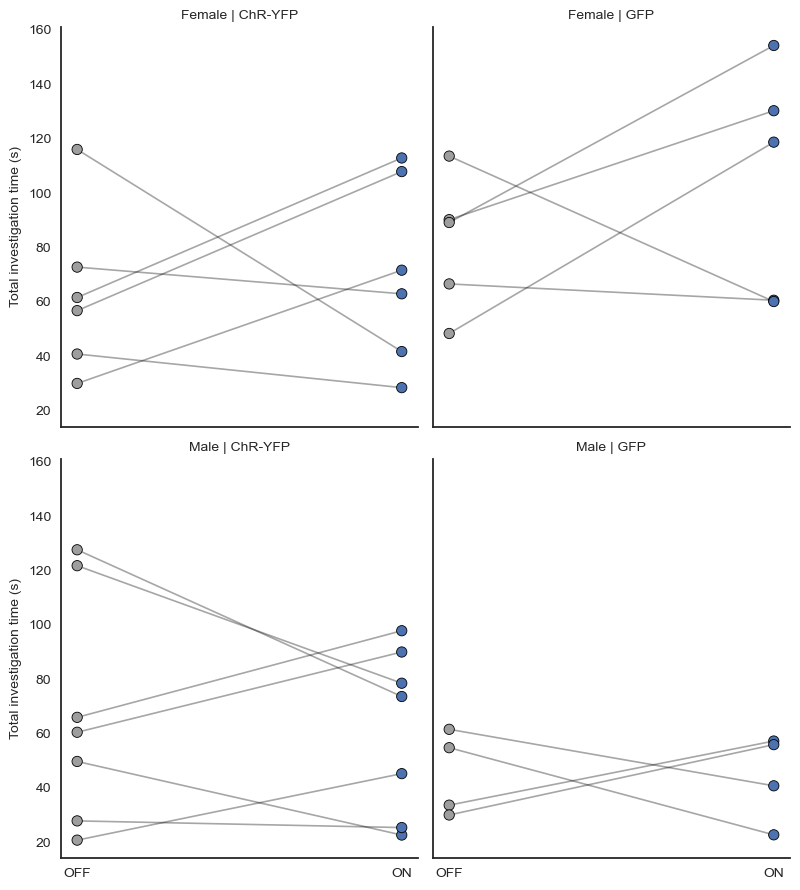

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("white")

palette_laser = {
    "OFF": "#9E9E9E",  # gray
    "ON":  "#4C72B0"   # blue
}

laser_order = ["OFF", "ON"]

g = sns.FacetGrid(
    invest_plot,
    row="SubjSex",
    col="Group",
    sharey=True,
    height=4.5,
    aspect=0.9
)

def paired_lines(data, **kwargs):
    ax = plt.gca()

    for subject, df_sub in data.groupby("SubjectID"):

        if set(df_sub["Laser"]) == set(laser_order):

            df_sub = df_sub.set_index("Laser").loc[laser_order]

            # numeric x positions for consistent alignment
            x_positions = [0, 1]

            ax.plot(
                x_positions,
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.35,
                linewidth=1.2,
                zorder=2
            )

            ax.scatter(
                x_positions,
                df_sub["InvestigationTime"],
                c=[palette_laser[l] for l in laser_order],
                s=55,
                edgecolor="black",
                linewidth=0.6,
                zorder=3
            )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(laser_order)

    # Clean axes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.3)
    ax.spines["bottom"].set_linewidth(1.3)
    ax.tick_params(width=1.2)

g.map_dataframe(paired_lines)

g.set_axis_labels("", "Total investigation time (s)")

# Cleaner title formatting
g.set_titles(row_template="{row_name}", col_template="{col_name}")

plt.tight_layout()
plt.show()


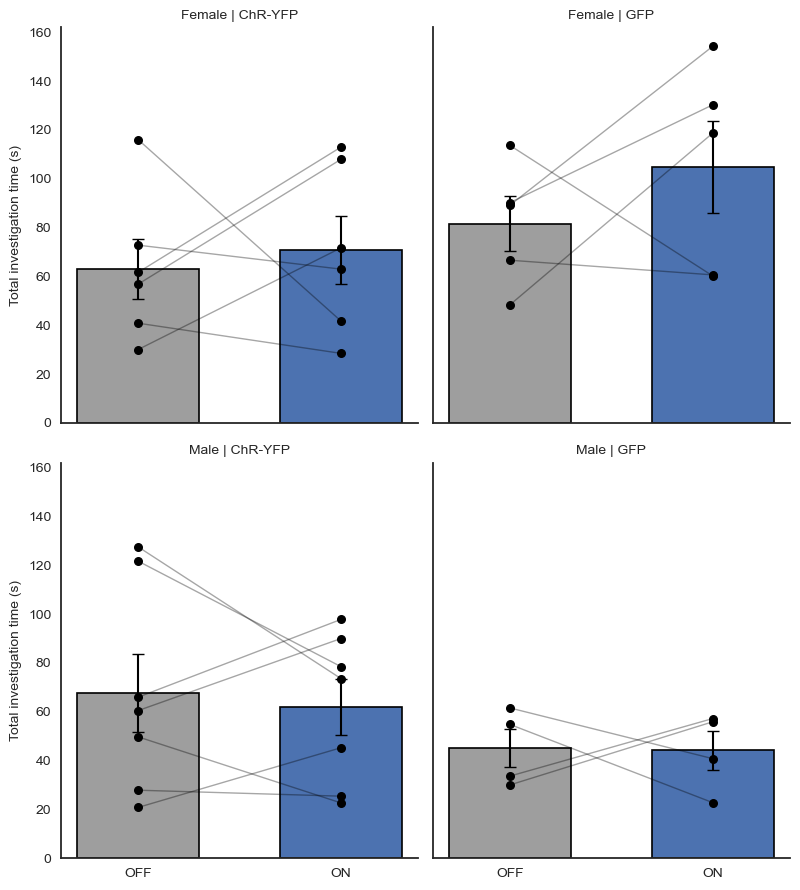

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import sem

sns.set_style("white")

palette_laser = {
    "OFF": "#9E9E9E",
    "ON": "#4C72B0"
}

laser_order = ["OFF", "ON"]

g = sns.FacetGrid(
    invest_plot,
    row="SubjSex",
    col="Group",
    sharey=True,
    height=4.5,
    aspect=0.9
)

def bar_with_pairs(data, **kwargs):
    ax = plt.gca()

    # --- Compute means + SEM ---
    means = []
    errors = []

    for laser in laser_order:
        vals = data[data["Laser"] == laser]["InvestigationTime"]
        means.append(vals.mean())
        errors.append(sem(vals))

    # --- Plot bars ---
    x = np.arange(len(laser_order))

    ax.bar(
        x,
        means,
        yerr=errors,
        capsize=4,
        color=[palette_laser[l] for l in laser_order],
        edgecolor="black",
        linewidth=1.2,
        width=0.6,
        zorder=1
    )

    # --- Overlay paired lines ---
    for subject, df_sub in data.groupby("SubjectID"):

        if set(df_sub["Laser"]) == set(laser_order):
            df_sub = df_sub.set_index("Laser").loc[laser_order]

            ax.plot(
                x,
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.35,
                linewidth=1,
                zorder=3
            )

            ax.scatter(
                x,
                df_sub["InvestigationTime"],
                color="black",
                s=30,
                zorder=4
            )

    # --- Clean styling ---
    ax.set_xticks(x)
    ax.set_xticklabels(laser_order)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.3)
    ax.spines["bottom"].set_linewidth(1.3)
    ax.tick_params(width=1.2)

g.map_dataframe(bar_with_pairs)

g.set_axis_labels("", "Total investigation time (s)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

plt.tight_layout()
plt.show()


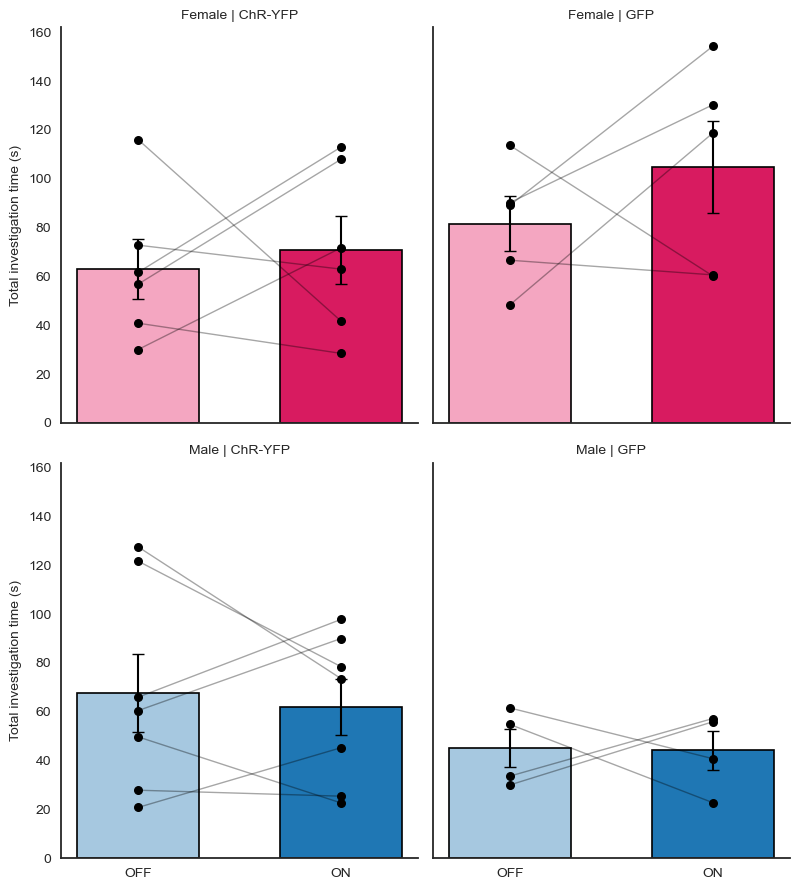

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import sem

sns.set_style("white")

laser_order = ["OFF", "ON"]

# --- Sex-specific color palettes ---
sex_palette = {
    "Female": {
        "OFF": "#F4A6C1",   # light pink
        "ON":  "#D81B60"    # darker pink
    },
    "Male": {
        "OFF": "#A6C8E0",   # light blue
        "ON":  "#1F77B4"    # darker blue
    }
}

g = sns.FacetGrid(
    invest_plot,
    row="SubjSex",
    col="Group",
    sharey=True,
    height=4.5,
    aspect=0.9
)

def bar_with_pairs(data, **kwargs):
    ax = plt.gca()

    sex = data["SubjSex"].iloc[0]  # get sex for this panel

    means = []
    errors = []

    for laser in laser_order:
        vals = data[data["Laser"] == laser]["InvestigationTime"]
        means.append(vals.mean())
        errors.append(sem(vals))

    x = np.arange(len(laser_order))

    # --- Bars colored by sex ---
    ax.bar(
        x,
        means,
        yerr=errors,
        capsize=4,
        color=[sex_palette[sex][l] for l in laser_order],
        edgecolor="black",
        linewidth=1.2,
        width=0.6,
        zorder=1
    )

    # --- Paired lines ---
    for subject, df_sub in data.groupby("SubjectID"):
        if set(df_sub["Laser"]) == set(laser_order):
            df_sub = df_sub.set_index("Laser").loc[laser_order]

            ax.plot(
                x,
                df_sub["InvestigationTime"],
                color="black",
                alpha=0.35,
                linewidth=1,
                zorder=3
            )

            ax.scatter(
                x,
                df_sub["InvestigationTime"],
                color="black",
                s=30,
                zorder=4
            )

    # --- Clean styling ---
    ax.set_xticks(x)
    ax.set_xticklabels(laser_order)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.3)
    ax.spines["bottom"].set_linewidth(1.3)
    ax.tick_params(width=1.2)

g.map_dataframe(bar_with_pairs)

g.set_axis_labels("", "Total investigation time (s)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

plt.tight_layout()
plt.show()


In [121]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Make sure categorical variables are set correctly
invest_plot["SubjSex"] = invest_plot["SubjSex"].astype("category")
invest_plot["Group"] = invest_plot["Group"].astype("category")
invest_plot["Laser"] = invest_plot["Laser"].astype("category")
invest_plot["SubjectID"] = invest_plot["SubjectID"].astype("category")

# Linear mixed model
model = smf.mixedlm(
    "InvestigationTime ~ SubjSex * Group * Laser",
    data=invest_plot,
    groups=invest_plot["SubjectID"]
)

result = model.fit()

print(result.summary())


                        Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        InvestigationTime
No. Observations:         44             Method:                    REML             
No. Groups:               22             Scale:                     939.2232         
Min. group size:          2              Log-Likelihood:            -182.9801        
Max. group size:          2              Converged:                 Yes              
Mean group size:          2.0                                                        
-------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                 63.027   13.248  4.757 0.000  37.061 88.993
SubjSex[T.Male]                            4.715   18.054  0.261 0.794 -30.671

In [124]:
delta = invest_plot.pivot_table(
    index=["SubjectID", "SubjSex", "Group"],
    columns="Laser",
    values="InvestigationTime"
).reset_index()

delta["Delta"] = delta["ON"] - delta["OFF"]

print(delta.groupby(["SubjSex", "Group"])["Delta"].mean())
print(delta.groupby(["SubjSex", "Group"])["Delta"].std())


SubjSex  Group  
Female   ChR-YFP     7.931500
         GFP        23.204400
Male     ChR-YFP    -5.837571
         GFP        -0.841500
Name: Delta, dtype: float64
SubjSex  Group  
Female   ChR-YFP    49.749463
         GFP        52.430771
Male     ChR-YFP    35.966312
         GFP        29.886280
Name: Delta, dtype: float64


C:\Users\sjs93\AppData\Local\Temp\ipykernel_41944\503093368.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  delta = invest_plot.pivot_table(
C:\Users\sjs93\AppData\Local\Temp\ipykernel_41944\503093368.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(delta.groupby(["SubjSex", "Group"])["Delta"].mean())
C:\Users\sjs93\AppData\Local\Temp\ipykernel_41944\503093368.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(delta.groupby(["S

In [125]:
delta.sort_values("Delta")


Laser,SubjectID,SubjSex,Group,OFF,ON,Delta
2,1_3,Female,ChR-YFP,116.066,41.753,-74.313
17,7_2,Male,ChR-YFP,127.581,73.623,-53.958
9,4_2,Female,GFP,113.625,60.144,-53.481
18,7_3,Male,ChR-YFP,121.728,78.516,-43.212
15,6_3,Male,GFP,54.800,22.763,-32.037
12,5_2,Male,ChR-YFP,49.742,22.686,-27.056
19,8_1,Male,GFP,61.558,40.790,-20.768
1,1_2,Female,ChR-YFP,40.841,28.480,-12.361
0,1_1,Female,ChR-YFP,72.801,62.983,-9.818
3,2_1,Female,GFP,66.622,60.618,-6.004


In [122]:
invest_plot.groupby(["SubjSex","Group","Laser"])["InvestigationTime"].mean()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_41944\35360708.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  invest_plot.groupby(["SubjSex","Group","Laser"])["InvestigationTime"].mean()


SubjSex  Group    Laser
Female   ChR-YFP  OFF       63.027167
                  ON        70.958667
         GFP      OFF       81.621000
                  ON       104.825400
Male     ChR-YFP  OFF       67.742000
                  ON        61.904429
         GFP      OFF       45.023500
                  ON        44.182000
Name: InvestigationTime, dtype: float64

In [123]:
invest_plot.groupby(["SubjSex","Group"])["SubjectID"].nunique()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_41944\433119113.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  invest_plot.groupby(["SubjSex","Group"])["SubjectID"].nunique()


SubjSex  Group  
Female   ChR-YFP    6
         GFP        5
Male     ChR-YFP    7
         GFP        4
Name: SubjectID, dtype: int64